In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv('Student_Marks.csv')

In [25]:
df.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [15]:
df.isnull().sum()

,0
number_courses,0
time_study,0
Marks,0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [16]:
df.describe()

,number_courses,time_study,Marks
count,100.000000,100.000000,100.000000
mean,5.290000,4.077140,24.417690
std,1.799523,2.372914,14.326199
min,3.000000,0.096000,5.609000
25%,4.000000,2.058500,12.633000
50%,5.000000,4.022000,20.059500
75%,7.000000,6.179250,36.676250
max,8.000000,7.957000,55.299000


<Axes: xlabel='time_study', ylabel='Marks'>

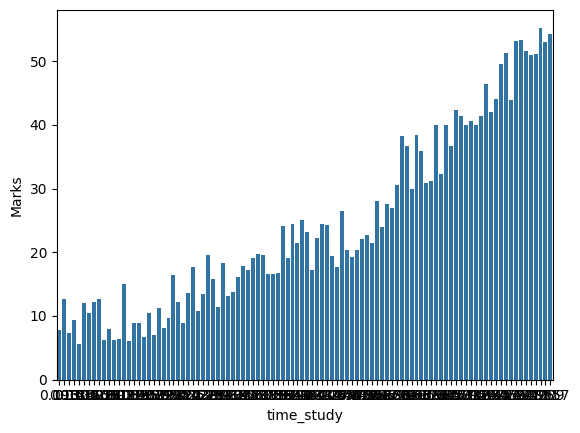

In [19]:
sns.barplot(data=df, x='time_study', y='Marks')

<Axes: xlabel='time_study', ylabel='Marks'>

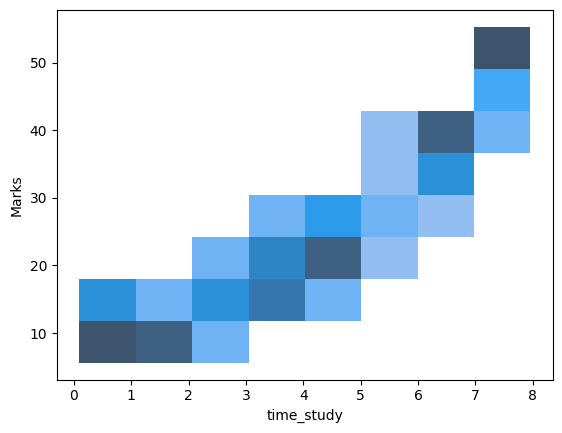

In [20]:
sns.histplot(data=df, x='time_study', y='Marks')

<Axes: xlabel='time_study', ylabel='Marks'>

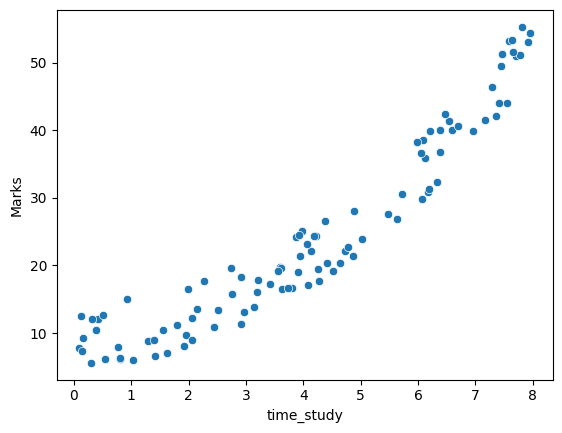

In [21]:
sns.scatterplot(data=df, x='time_study', y='Marks')

<Axes: >

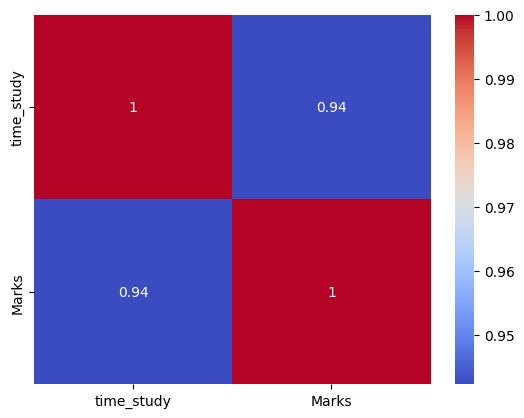

In [24]:
qsns.heatmap(df[['time_study', 'Marks']].corr(), annot=True, cmap='coolwarm')

In [33]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [34]:
# Separate features and target
X = df[['number_courses', 'time_study']]
y = df['Marks']

# Split into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define our candidate models
models = {
    'Multiple Linear Regression': LinearRegression(),
    'Polynomial Regression (Degree 2)': make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    'Ridge Regression (Regularized Poly)': make_pipeline(PolynomialFeatures(degree=2), Ridge(alpha=1.0))
}

# Evaluate each model
results_list = []

for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)

    # Predict on test set
    y_pred = model.predict(X_test)

    # Calculate performance metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # 5-Fold Cross Validation to verify generalizability
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    cv_mean = cv_scores.mean()

    results_list.append({
        'Model Name': name,
        'Test R² Score': r2,
        'Cross-Val R² (Mean)': cv_mean,
        'MAE': mae,
        'RMSE': rmse
    })

# Format and display the performance table
results_df = pd.DataFrame(results_list)
print("\n=== MODEL PERFORMANCE COMPARISON ===")
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


=== MODEL PERFORMANCE COMPARISON ===
                         Model Name  Test R² Score  Cross-Val R² (Mean)    MAE   RMSE
         Multiple Linear Regression         0.9460               0.9325 3.0793 3.7684
   Polynomial Regression (Degree 2)         0.9997               0.9996 0.2278 0.2853
Ridge Regression (Regularized Poly)         0.9996               0.9995 0.2410 0.3066


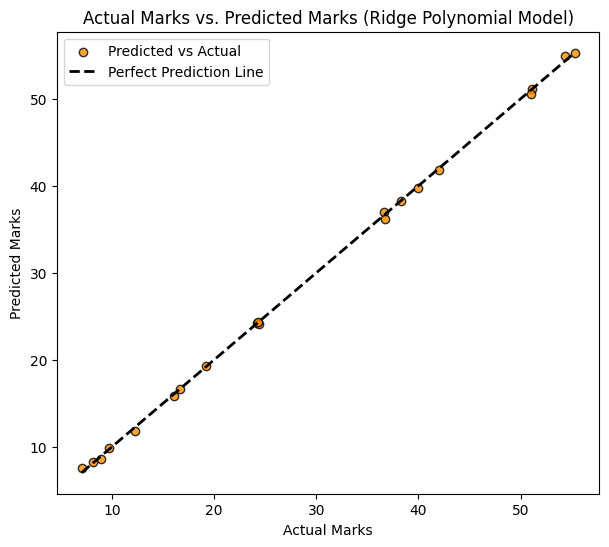

In [35]:
# Pick the best model (Ridge Regression with Polynomial Features)
best_model = models['Ridge Regression (Regularized Poly)']
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, color='darkorange', edgecolors='k', alpha=0.8, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.title('Actual Marks vs. Predicted Marks (Ridge Polynomial Model)')
plt.xlabel('Actual Marks')
plt.ylabel('Predicted Marks')
plt.legend()
plt.show()